In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df=sns.load_dataset("titanic")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.loc[0,'embark_town']='southampton'
df.loc[1,'embark_town']='SOUTHAMPTON'
df.loc[2,'embark_town']='Southampton'
print(df['embark_town'].unique())

['southampton' 'SOUTHAMPTON' 'Southampton' 'Queenstown' 'Cherbourg' nan]


In [7]:
df['embark_town']=df['embark_town'].str.title()

In [8]:
print(df['embark_town'].unique())

['Southampton' 'Queenstown' 'Cherbourg' nan]


In [9]:
print(df['embark_town'].isnull().sum())

2


In [10]:
df['embark_town']=df['embark_town'].fillna('Kingstown')

In [11]:
print(df['embark_town'].unique())

['Southampton' 'Queenstown' 'Cherbourg' 'Kingstown']


## 2.Duplicate Rows
* A Duplicate 

#### Create Duplicate Records

In [12]:
duplicate_rows=df.iloc[:5]
df_dup=pd.concat([df,duplicate_rows])
print(df_dup.shape)

(896, 15)


#### Find Duplicates

In [13]:
print(df_dup.duplicated().sum())

112


#### View Duplicate Rows

In [14]:
df_dup[df_dup.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Southampton,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False


#### Remove Duplicates

In [15]:
df_dup=df_dup.drop_duplicates()
print(df_dup.duplicated().sum())

0


In [16]:
df.loc[0,'embark_town']='Southamton'
df.loc[1,'embark_town']='Southhampton'

In [17]:
# Fix Types
df['embark_town']=df['embark_town'].replace({
    'Southamton':'Southampton',
    'Southhampton':'Southampton'
})

In [18]:
# Verify:

print(df['embark_town'].value_counts())

embark_town
Southampton    645
Cherbourg      167
Queenstown      77
Kingstown        2
Name: count, dtype: int64


### 4. Unit Mismatch

In [19]:
df.loc[0,'age']=240
df.loc[1,'age']=300

In [20]:
# Detect Unusual Values
df['age'].describe()

count    714.000000
mean      30.371387
std       19.362012
min        0.420000
25%       20.125000
50%       28.000000
75%       38.750000
max      300.000000
Name: age, dtype: float64

In [21]:
# Fix Unit Mismatch
# Convert months to years.

df.loc[df['age']>120,'age']=(
    df.loc[df['age']>120,'age']/12
)

#verify:
df['age'].describe()

count    714.000000
mean      29.678109
std       14.525902
min        0.420000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

### 5.Wrong Category Labels
* df['Survived']
* contains:
* 0
* 1
* Not Very readable

In [22]:
df['survived_label']=df['survived'].map({
    0:'No',
    1:'Yes'
})

print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  20.0      1      0   7.2500        S  Third   
1         1       1  female  25.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone survived_label  
0    man        True  NaN  Southampton    no  False             No  
1  woman       False    C  Southampton   yes  False            Yes  
2  woman       False  NaN  Southampton   yes   True            Yes  
3  woman       False    C  Southampton   yes  False            Yes  
4    man        True  NaN  Southampton    no   True             No  


In [23]:
# Check:
df.isnull().mean()

survived          0.000000
pclass            0.000000
sex               0.000000
age               0.198653
sibsp             0.000000
parch             0.000000
fare              0.000000
embarked          0.002245
class             0.000000
who               0.000000
adult_male        0.000000
deck              0.772166
embark_town       0.000000
alive             0.000000
alone             0.000000
survived_label    0.000000
dtype: float64

In [24]:
# Remove
df.drop(columns=['deck'],inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,survived_label
0,0,3,male,20.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,No
1,1,1,female,25.0,1,0,71.2833,C,First,woman,False,Southampton,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,No


### Handling Null Values in Titanic Dataset

In [25]:
#Method 1: Mean Imputation

# Peplace missing values with the average value.'
df['age']=df['age'].fillna(df['age'].mean())
df.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,survived_label
0,0,3,male,20.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False,No
1,1,1,female,25.000000,1,0,71.2833,C,First,woman,False,Southampton,yes,False,Yes
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Yes
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Yes
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,No
5,0,3,male,29.678109,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,No
6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,Southampton,no,True,No
7,0,3,male,2.000000,3,1,21.0750,S,Third,child,False,Southampton,no,False,No
8,1,3,female,27.000000,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,Yes
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,Yes


### Method 2: Median Imputation

Replace missing values with the middle value

Example:



Let's Check age distribution.

df['age'].skew()

if skewness is high:

Use Median.

If data is nearly normal:

use mean

### Method 3: Mode Imputation

Replace missing values with most frequent value.

df['embarked_mode']=df['embarked'].fillna(df['embarked'],mode()[0])


Method 4: Forward Fill (FFill)

* Use the previous value to fill missing value

In [26]:
# Apply Forward Fill
df['embarked_ffill']=df['embarked'].ffill()

#Check Missing Values
print(df['embarked_ffill'].isnull().sum())

0


### Method 5: KNN Imputation
* K-Nearest Neighbors(KNN) Imputation fills missing values using imformation from similar rows.
* Instead of using a single value (mean/median), it finds the K Most similar records and uses their values.

In [27]:
import pandas as pd
import numpy as np

data={
    'age':[22,25,np.nan,24,23],
    'fare':[7.25,8.05,7.90,8.00,7.50]
}

df=pd.DataFrame(data)

print(df)

    age  fare
0  22.0  7.25
1  25.0  8.05
2   NaN  7.90
3  24.0  8.00
4  23.0  7.50


In [28]:
# Apply KNN Imputation

from sklearn.impute import KNNImputer

KNN=KNNImputer(n_neighbors=3)
df_KNN=pd.DataFrame(
    KNN.fit_transform(df),
    columns=df.columns)

print(df,KNN)

#sklearn -> Scikit-Learn Library for Machine Learning and Data Preprocessing
#impute -> Module for handling missing values
#KNNImputer -> class that fills missing values using the K-Nearest Neighbour Algorithm
#fit_transform(df) ->Learns from the data and fills missing values
# Converts the result back into a pandas dataframe.


    age  fare
0  22.0  7.25
1  25.0  8.05
2   NaN  7.90
3  24.0  8.00
4  23.0  7.50 KNNImputer(n_neighbors=3)


In [29]:
from sklearn.impute import KNNImputer

df=sns.load_dataset('titanic')

df['embarked_ffill']=df['embarked'].ffill()

#KNN Impuutation for age
cols=[
    'age',
    'fare',
    'sibsp',
    'parch',
    'pclass'
]

imputer=KNNImputer(n_neighbors=5)
df[cols]=imputer.fit_transform(df[cols])
print(df.isnull().sum())

survived            0
pclass              0
sex                 0
age                 0
sibsp               0
parch               0
fare                0
embarked            2
class               0
who                 0
adult_male          0
deck              688
embark_town         2
alive               0
alone               0
embarked_ffill      0
dtype: int64


**Backward Fill**

df.fillna(method='bfill',inplace=True)

**or**

df.bfill(inplace=True)

### Encoding Using Titanic Dataset

**What is Encoding?**
* Machine Learning models work with numbers,not text.

**Example:**
Sex
* male
* female
* male
* A Model cannot directly understand "Male" and "Female".
* We Convert categories into numbers using Encoding.

### Types of Encoding
#### 1.**Label Encoding (Ordinal Data)**
   * Assigns a number to each Category.

**Example:**

**Size**
   * Small
   * Medium
   * Large

**Becomes as Size**
   * 0
   * 1
   * 2
   * The Order Matters

### When to use Label Encoding?

   1. **Ordinal Categories**

        Examples:
      
        Small<Medium<Large
      
        Low<Medium<High
      
        Poor<Average<Good

   3. **Nominal Categories**

        Examples:
      
        Red,Blue,Green
      
        Male, Female
      
        India, USA, UK

#### 2. One-Hot Encoding (Nominal Data)
* Creates a Seperate binary column for each category.

### When to use One-Hot Encoding?
**Nominal Categories**

Examples:

Country,Gender,Color,City,Department.

### 3. Target Encoding
* Replace categories with the avarage value of the target variable.

#### Why use Target Encoding?

Imagine:

5000 Cities

One-Hot Encoding would Create:

5000 Columns

Not Practical

Target Encoding Creates:

1 Colums

In [30]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load Titanic Dataset
df=sns.load_dataset('titanic')

#Label Encoding
le=LabelEncoder()

df['sex_encoded']=le.fit_transform(
    df['sex']
)

# One-Hot Encoding

df=pd.get_dummies(
    df,
    columns=['embarked']
)

# Target Encoding
target_map=df.groupby('pclass')['survived'].mean()

df['class_target']=(df['pclass'].map(target_map))

print(df.head())


   survived  pclass     sex   age  sibsp  parch     fare  class    who  \
0         0       3    male  22.0      1      0   7.2500  Third    man   
1         1       1  female  38.0      1      0  71.2833  First  woman   
2         1       3  female  26.0      0      0   7.9250  Third  woman   
3         1       1  female  35.0      1      0  53.1000  First  woman   
4         0       3    male  35.0      0      0   8.0500  Third    man   

   adult_male deck  embark_town alive  alone  sex_encoded  embarked_C  \
0        True  NaN  Southampton    no  False            1       False   
1       False    C    Cherbourg   yes  False            0        True   
2       False  NaN  Southampton   yes   True            0       False   
3       False    C  Southampton   yes  False            0       False   
4        True  NaN  Southampton    no   True            1       False   

   embarked_Q  embarked_S  class_target  
0       False        True      0.242363  
1       False       False      0

### Feature Scaling Using Titanic Dataset

**what is Feature Scaling?**

Feature Scaling transforms numerical Features to a similar scale.

**Why is it needed?**

In the Titanic Dataset

**Example:**

Feature Range Age 0-80 Fare 0-512

Here, Fare has a much larger range than Age.

Many ML algorithms calculate distances, so Fare can dominate the model.

#### 1.MinMaxScaler

scales values between 0 to 1.

**Advantages**

* Preserves shape or distribution
* values always between 0 and 1
* useful for Neural Networks.

**Disadvantages**

* Sensitive to Outliers


### 2. StandardScaler

Centers data around mean=0 and standard deviation=1.

**Advantages**
* Works well for normally distributed data
* Commonly Used
* Required by many Algorithms

**Best For**

Logistic Regression,SVM, PCA, KNN, Linear Regression

**Disadvantages**
* Still Affected by extreme outliers

### 3. RobustScaler

Uses Median and IQR instead of Mean and Standard Deviation.

**Advantages**
* Handles Outliers Well
* Better for Skewed distributions

**Disadvantages**
* Values are not limited to 0-1

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

df[['age_minmax','fare_minmax']]=scaler.fit_transform(df[['age','fare']])

df[['age_minmax','fare_minmax']].head()

,age_minmax,fare_minmax
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


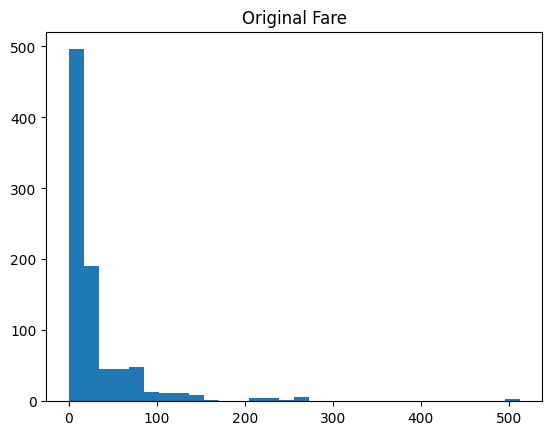

(array([496., 191.,  45.,  45.,  48.,  13.,  11.,  11.,   9.,   2.,   0.,
          0.,   5.,   4.,   2.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

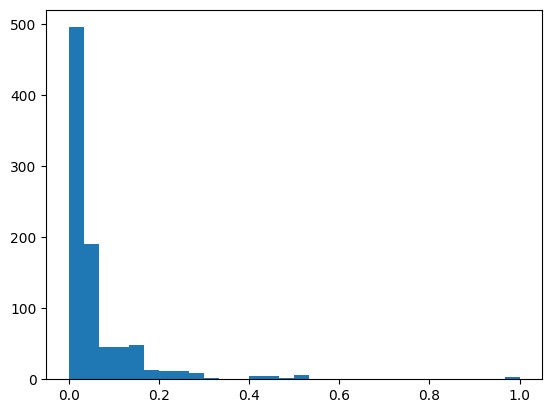

In [32]:
import matplotlib.pyplot as plt

plt.hist(df['fare'].dropna(),bins=30)
plt.title("Original Fare")
plt.show()

plt.hist(df['fare_minmax'],bins=30)

In [33]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()

df[['age_robust','fare_robust']]=scaler.fit_transform(df[['age','fare']])

df[['age_robust','fare_robust']].head()

,age_robust,fare_robust
0,-0.335664,-0.312011
1,0.559441,2.461242
2,-0.111888,-0.282777
3,0.391608,1.673732
4,0.391608,-0.277363


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Why Detect Outliers?**


### Method 1: Visual Detection Using Box Plot
* A Box Plot Quickly Shows:

1. Minimum Value
2. Q1 (25th Percentile)
3. Median
4. Q3 (75th Percentile)
5. Maximum Value
6. Outliers

### Method 2: IQR Method

IQR=Interquartile Range

Formula: IQR=Q3-Q1

Step 1: Calculate IQR

Step 2: Calculate Limits - Lower Limit & Upper Limit

Step 3: Detect Outliers

### Method 3: Z-Score Method

* Measures how many standard deviations a value is from the mean.

Step 1: Calculate Z-Score

Step 3: Detect Outliers


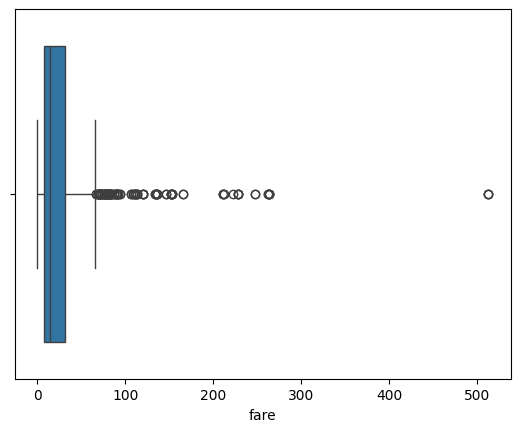

IQR Outliers: 116
Z-score Outliers: 20


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

#Load Titanic Dataset
df=sns.load_dataset('titanic')

# Box Plot
sns.boxplot(x=df['fare'])
plt.show()

# IQR Method
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers_iqr=df[(df['fare']<lower) | (df['fare']>upper)]

print("IQR Outliers:",len(outliers_iqr))

# Z-Score Method
df['fare_zscore']=zscore(df['fare'])

outliers_z=df[abs(df['fare_zscore'])>3]

print("Z-score Outliers:",len(outliers_z))